In [29]:
import pandas as pd
import numpy as np

In [30]:
df= pd.read_csv("application_train.csv")

In [31]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
df.shape  #finds the shape of our dataframe. How many rows, and columns are there. No brackets needed, it is a property not a method.

(307511, 122)

In [33]:
Default = df['TARGET'].sum()
Total = df['TARGET'].count()
Non_Default = Total - Default
Default_rate = (Default/Total) *100

In [34]:
print (Default)
print (Total)
print (Non_Default)
print (Default_rate)

24825
307511
282686
8.072881945686495


In [16]:
# This is a classic imbalanced classification problem. For every 1 defaulter, there are roughly 11 non-defaulters.
# A model that predicts "nobody defaults" would be 91.93% accurate. That sounds good but is completely useless for a bank.
# This is why we evaluate PD models using AUROC and Gini, not accuracy.
# It also means when we do our train-test split, we must use stratified splitting to preserve this 8/92 ratio in both sets.

In [35]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [36]:
pd.set_option('display.max_columns', None)

In [37]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [39]:
print(df.dtypes.value_counts())

float64    65
int64      41
object     16
Name: count, dtype: int64


In [41]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include = ['object']).columns

print (len(numeric_cols))
print (len(categorical_cols))

106
16


In [43]:
missing_pct = df.isnull().sum()/len(df) *100
high_missing = missing_pct[missing_pct>30].sort_values(ascending = False)

In [44]:
print(high_missing)
print(len(high_missing))

COMMONAREA_AVG                  69.872297
COMMONAREA_MEDI                 69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_AVG            68.354953
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
FLOORSMIN_AVG                   67.848630
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_AVG                 66.497784
YEARS_BUILD_MEDI                66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

In [45]:
print (missing_pct)

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64


In [48]:
pd.set_option('display.max_rows', 200)
print (df.dtypes)
print(len(df.dtypes))

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE               object
CODE_GENDER                      object
FLAG_OWN_CAR                     object
FLAG_OWN_REALTY                  object
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                  object
NAME_INCOME_TYPE                 object
NAME_EDUCATION_TYPE              object
NAME_FAMILY_STATUS               object
NAME_HOUSING_TYPE                object
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64


In [49]:
#Summary so far:
# Total Borrowers (rows): 307511
# Total features (columns): 122

#Target Variables
#Default Rate = 8.07%
# Defaulters (Target=1): 24825
# Non Defaulters (Target=0): 282,686

#Numeric_features = 106
# Categorical Features = 16
#Columns with more than 30% missing: 50 out of 122 (41% of feature set)

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
target_counts = df['TARGET'].value_counts()

In [52]:
target_pct = df['TARGET'].value_counts(normalize = True) *100

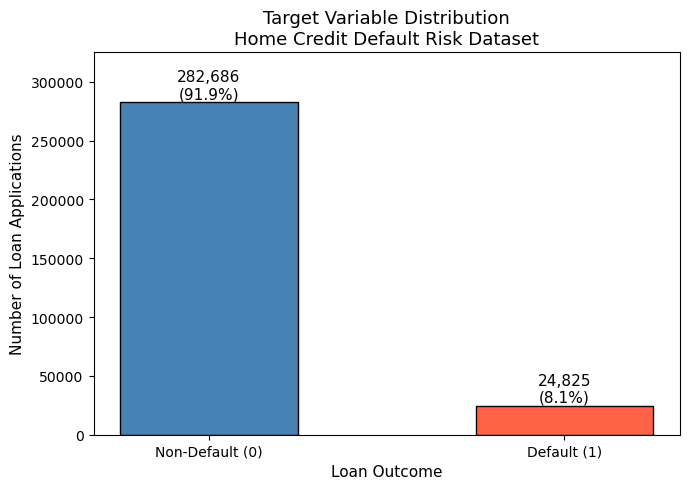

In [56]:
fig, ax = plt.subplots(figsize = (7,5))
bars = ax.bar(
    ['Non-Default (0)', 'Default (1)'],
    target_counts.values,
    color = ['steelblue', 'tomato'],
    edgecolor = 'black',
    width = 0.5
)

for i, (count, pct) in enumerate (zip(target_counts.values, target_pct.values)):
    ax.text(
        i,
        count + 3000,
        f'{count:,}\n({pct:.1f}%)',
        ha = 'center',
        fontsize = 11
    )

ax.set_title('Target Variable Distribution\nHome Credit Default Risk Dataset', fontsize=13)
ax.set_ylabel('Number of Loan Applications', fontsize=11)
ax.set_xlabel('Loan Outcome', fontsize=11)
ax.set_ylim(0, max(target_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

In [57]:
print (categorical_cols)

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [60]:
cat_vars = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE']
#These are the categorical variable we want to analyse

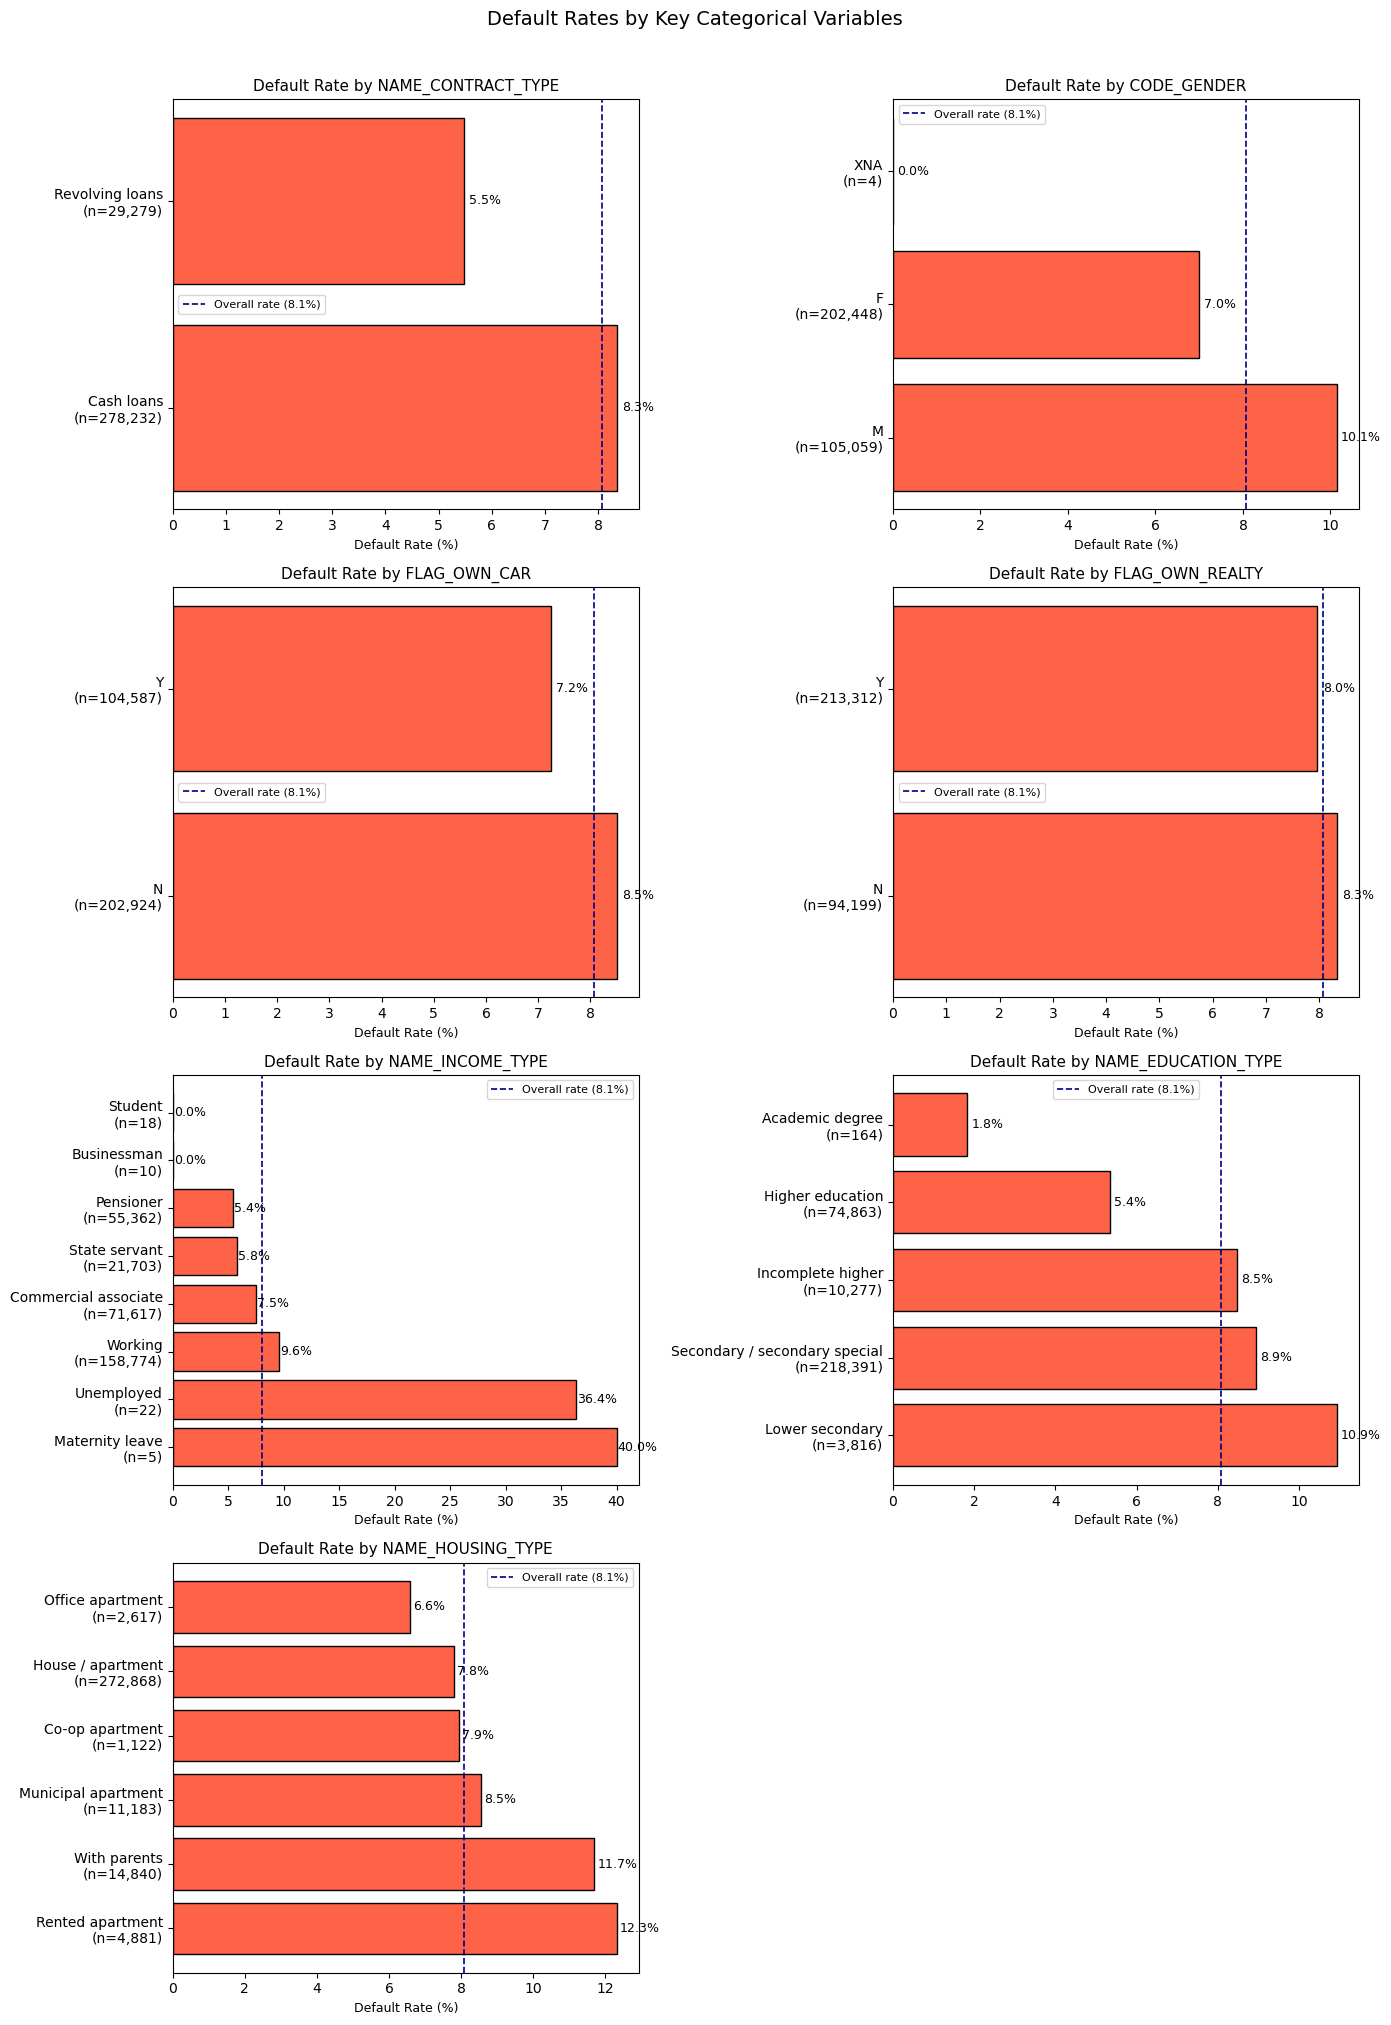

In [63]:
fix, axes = plt.subplots(4, 2, figsize = (14,20))
axes = axes.flatten()
for i, var in enumerate (cat_vars):
    ax = axes[i]
    default_rate = df.groupby(var)['TARGET'].mean().sort_values(ascending = False) *100
    count = df[var].value_counts()
    labels = [f'{cat}\n(n={count[cat]:,})' for cat in default_rate.index]
    ax.barh(labels, default_rate.values, color='tomato', edgecolor='black')
    ax.axvline(df['TARGET'].mean() * 100, color='navy',
               linestyle='--', linewidth=1.2, label='Overall rate (8.1%)')
    for j, val in enumerate(default_rate.values):
        ax.text(val + 0.1, j, f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Default Rate by {var}', fontsize=11)
    ax.set_xlabel('Default Rate (%)', fontsize=9)
    ax.legend(fontsize=8)

axes[7].set_visible(False) #hide the unused 8th subplot
plt.suptitle('Default Rates by Key Categorical Variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
print (numeric_cols.value_counts())

SK_ID_CURR                      1
DAYS_LAST_PHONE_CHANGE          1
OBS_60_CNT_SOCIAL_CIRCLE        1
DEF_30_CNT_SOCIAL_CIRCLE        1
OBS_30_CNT_SOCIAL_CIRCLE        1
TOTALAREA_MODE                  1
NONLIVINGAREA_MEDI              1
NONLIVINGAPARTMENTS_MEDI        1
LIVINGAREA_MEDI                 1
LIVINGAPARTMENTS_MEDI           1
LANDAREA_MEDI                   1
FLOORSMIN_MEDI                  1
FLOORSMAX_MEDI                  1
ENTRANCES_MEDI                  1
ELEVATORS_MEDI                  1
COMMONAREA_MEDI                 1
YEARS_BUILD_MEDI                1
YEARS_BEGINEXPLUATATION_MEDI    1
BASEMENTAREA_MEDI               1
APARTMENTS_MEDI                 1
NONLIVINGAREA_MODE              1
NONLIVINGAPARTMENTS_MODE        1
LIVINGAREA_MODE                 1
LIVINGAPARTMENTS_MODE           1
LANDAREA_MODE                   1
DEF_60_CNT_SOCIAL_CIRCLE        1
FLAG_DOCUMENT_2                 1
TARGET                          1
FLAG_DOCUMENT_3                 1
AMT_REQ_CREDIT

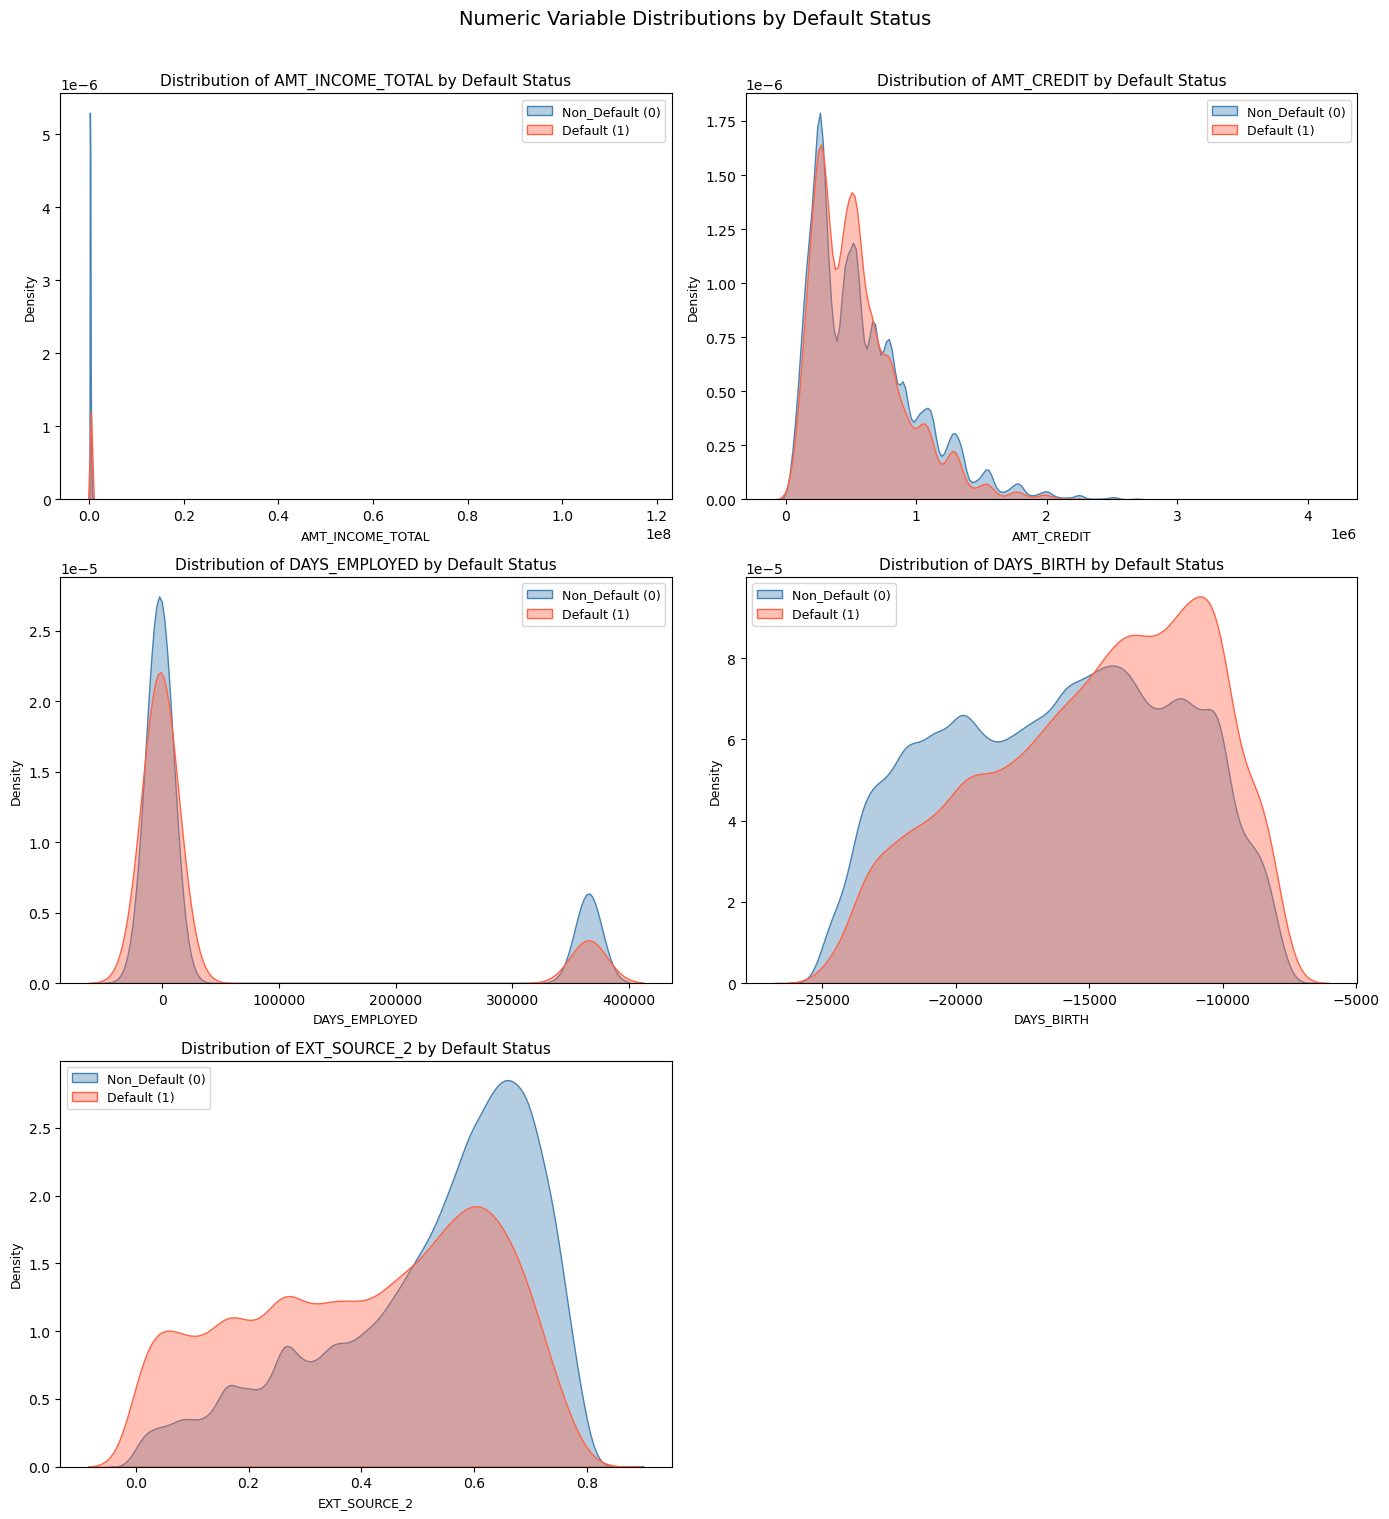

In [69]:
num_vars = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'EXT_SOURCE_2']
non_default = df[df['TARGET'] == 0]
default = df[df['TARGET'] == 1]

fig, axes = plt.subplots(3, 2, figsize = (14,15))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]

    #kde plot for non-defaulter
    sns.kdeplot(non_default[var].dropna(), ax=ax,
               label = 'Non_Default (0)', color = 'steelblue',
               fill = True, alpha = 0.4)

    #kde plot for defaulters
    sns.kdeplot(default[var].dropna(), ax=ax,
               label = 'Default (1)', color = 'tomato',
               fill = True, alpha = 0.4)

    ax.set_title(f'Distribution of {var} by Default Status', fontsize = 11)
    ax.set_xlabel(var, fontsize = 9)
    ax.set_ylabel('Density', fontsize = 9)
    ax.legend(fontsize = 9)

axes[5].set_visible(False)   #hide the unused 6th plot

plt.suptitle('Numeric Variable Distributions by Default Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X = df.drop(['TARGET', 'SK_ID_CURR'], axis = 1)
y = df['TARGET']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

In [83]:
print("Default rate verification:")
print(f"  Full dataset:   {y.mean():.4f}")
print(f"  Training set:   {y_train.mean():.4f}")
print(f"  Test set:       {y_test.mean():.4f}")

print("\nShape verification:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

Default rate verification:
  Full dataset:   0.0807
  Training set:   0.0807
  Test set:       0.0807

Shape verification:
  X_train: (246008, 120)
  X_test:  (61503, 120)
  y_train: (246008,)
  y_test:  (61503,)


In [85]:
X_train['DAYS_EMPLOYED_ANOMALY'] = (X_train['DAYS_EMPLOYED'] == 365243).astype(int)
X_test['DAYS_EMPLOYED_ANOMALY'] = (X_test['DAYS_EMPLOYED'] == 365243).astype(int)

In [86]:
X_train['DAYS_EMPLOYED'] = X_train['DAYS_EMPLOYED'].replace(365243, np.nan)
X_test['DAYS_EMPLOYED'] = X_test['DAYS_EMPLOYED'].replace(365243, np.nan)

In [87]:
X_train['AGE_YEARS'] = X_train['DAYS_BIRTH'] / -365
X_test['AGE_YEARS'] = X_test['DAYS_BIRTH'] / -365

In [88]:
X_train['DAYS_EMPLOYED_CLEAN'] = X_train['DAYS_EMPLOYED'] * -1
X_test['DAYS_EMPLOYED_CLEAN'] = X_test['DAYS_EMPLOYED'] * -1

In [89]:
X_train['DEBT_BURDEN_RATIO'] = X_train['AMT_ANNUITY'] / X_train['AMT_INCOME_TOTAL']
X_test['DEBT_BURDEN_RATIO'] = X_test['AMT_ANNUITY'] / X_test['AMT_INCOME_TOTAL']

In [93]:
print (X_train['DAYS_EMPLOYED_ANOMALY'].value_counts())

DAYS_EMPLOYED_ANOMALY
0    201865
1     44143
Name: count, dtype: int64


In [102]:
print ("AGE YEARS")
print (round(X_train['AGE_YEARS'].min(), 2))
print (round(X_train['AGE_YEARS'].max(), 2))

AGE YEARS
20.52
69.12


In [103]:
print ("DAYS EMPLOYED CLEAN")
print (round(X_train['DAYS_EMPLOYED_CLEAN'].min(), 2))
print (round(X_train['DAYS_EMPLOYED_CLEAN'].max(), 2))

DAYS EMPLOYED CLEAN
-0.0
17912.0


In [104]:
print ("DEBT BURDEN RATIO RANGE")
print (round(X_train['DEBT_BURDEN_RATIO'].min(), 2))
print (round(X_train['DEBT_BURDEN_RATIO'].max(), 2))

DEBT BURDEN RATIO RANGE
0.0
1.57


In [105]:
from sklearn.impute import SimpleImputer

In [106]:
num_cols_with_missing = X_train.select_dtypes(include = ['float64', 'int64']).columns[X_train.select_dtypes(include = ['float64', 'int64']).isnull().any()].tolist()

In [107]:
cat_cols_with_missing = X_train.select_dtypes(include = ['object']).columns[X_train.select_dtypes(include =['object']).isnull().any()].tolist()

In [108]:
print (f'Numerical Columns to impute: {len(num_cols_with_missing)}')
print (f'Categorical Columns to impute: {len(cat_cols_with_missing)}')

Numerical Columns to impute: 64
Categorical Columns to impute: 6


In [109]:
ext_source_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in X_train.columns]
for col in ext_source_cols:
    X_train[f'{col}_MISSING'] = X_train[col].isnull().astype(int)
    X_test[f'{col}_MISSING'] = X_test[col].isnull().astype(int)
print (f"\nExternal Source missingness flag created: {[f'{c}_MISSING' for c in ext_source_cols]}")


External Source missingness flag created: ['EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']


In [110]:
building_cols = [c for c in X_train.columns if any(keyword in c for keyword in ['COMMONAREA', 'LIVINGAREA', 'LIVINGAPARTMENTS',
        'NONLIVINGAREA', 'NONLIVINGAPARTMENTS', 'APARTMENTS',
        'BASEMENTAREA', 'YEARS_BUILD', 'YEARS_BEGINEXPLUATATION',
        'FLOORSMAX', 'FLOORSMIN', 'ELEVATORS', 'ENTRANCES',
        'LANDAREA', 'FONDKAPREMONT', 'HOUSETYPE', 'TOTALAREA',
        'WALLSMATERIAL', 'EMERGENCYSTATE'])]
X_train['BUILDING_INFO_MISSING'] = X_train[building_cols].isnull().all(axis = 1).astype(int)
X_test['BUILDING_INFO_MISSING'] = X_test[building_cols].isnull().all(axis = 1).astype(int)
print (f'BUILDING INFO MISSING flag created across {len(building_cols)} building cols')

BUILDING INFO MISSING flag created across 47 building cols


In [111]:
num_imputer = SimpleImputer(strategy ='median')
num_imputer.fit(X_train[num_cols_with_missing])

SimpleImputer(strategy='median')

In [112]:
X_train[num_cols_with_missing] = num_imputer.transform(X_train[num_cols_with_missing])
X_test[num_cols_with_missing] = num_imputer.transform(X_test[num_cols_with_missing])

In [113]:
X_train[cat_cols_with_missing] = X_train[cat_cols_with_missing].fillna('Unknown')
X_test[cat_cols_with_missing] = X_test[cat_cols_with_missing].fillna('Unknown')

In [115]:
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()
print(f"\nMissing values remaining in X_train: {train_missing}")
print(f"Missing values remaining in X_test:  {test_missing}")


Missing values remaining in X_train: 0
Missing values remaining in X_test:  0


In [118]:
if train_missing == 0 and test_missing == 0:
    print("Imputation complete. No missing values remain.")
else:
    print("WARNING: Missing values still present. Investigate before proceeding.")

Imputation complete. No missing values remain.


In [119]:
print(building_cols)

['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [121]:
#WOE and IV calculations
def calculate_woe_iv(df, feature, target):
    total_goods = (df[target] == 0).sum()
    total_bads = (df[target] == 1).sum()

    stats = df.groupby(feature)[target].agg(
        total = 'count',
        bads = 'sum'
    ).reset_index()

    stats['goods'] = stats['total'] - stats['bads']

    stats['dist_goods'] = (stats['goods']+ 0.0001)/total_goods
    stats['dist_bads'] = (stats['bads']+0.0001)/total_bads

    stats['woe'] = np.log(stats['dist_goods']/stats['dist_bads'])
    stats['iv_contribution'] = (stats['dist_goods'] - stats['dist_bads']) * stats['woe']

    iv_total = stats['iv_contribution'].sum()

    return stats, iv_total

In [126]:
def bin_numeric (series, n_bins=10):
    binned, boundaries = pd.qcut(series, q=n_bins, duplicates = 'drop', retbins =True)   # retbins=True returns the actual boundary values alongside the binned Series
    binned = binned.astype(str)
    binned = binned.fillna('Missing')
    return binned, boundaries
def apply_bins(series, boundaries):
    binned = pd.cut(series, bins=boundaries, include_lowest = True) # include_lowest=True ensures minimum value falls inside first bin
    binned = binned.astype(str)
    binned = binned.fillna('Missing')
    return binned

In [127]:
def check_monotonicity(woe_table, feature):
    woe_values = woe_table['woe'].tolist()
    is_increasing = all(
        woe_values[i] < woe_values[i+1]
        for i in range(len(woe_values) -1)
    )
    is_decreasing = all(
        woe_values[i] > woe_values[i+1]
        for i in range(len(woe_values) -1)
    )
    is_monotonic = is_increasing or is_decreasing
    if not is_monotonic:
        print (f'WARNING!: {feature} is not monotonic. Consider Reducing Bins.')
    return is_monotonic

In [128]:
def apply_woe_transform(X_train, X_test, feature, woe_table):
    woe_dict = dict(zip(woe_table[feature], woe_table['woe']))
    mean_woe = woe_table['woe'].mean()
    woe_col = f'{feature}_WOE'
    X_train[woe_col] = X_train[feature].map(woe_dict).fillna(mean_woe)
    X_test[woe_col] = X_test[feature].map(woe_dict).fillna(mean_woe)
    return X_train, X_test

In [129]:
def run_woe_pipeline(X_train, X_test, y_train, cat_cols, num_cols):
    train_df = X_train.copy()
    train_df['TARGET'] = y_train.values

    iv_results = {}
    for feature in cat_cols:
        woe_table, iv = calculate_woe_iv(train_df, feature, 'TARGET')
        X_train, X_test = apply_woe_transform(X_train, X_test, feature, woe_table)
        iv_results[feature] = iv

    for feature in num_cols:
        bin_col = f'{feature}_BIN'
        train_df[bin_col], boundaries = bin_numeric(train_df[feature], n_bins = 10)
        X_train[bin_col], _ = bin_numeric(X_train[feature], n_bins = 10)
        X_test[bin_col] = apply_bins(X_test[feature], boundaries)
        woe_table, iv = calculate_woe_iv(train_df, bin_col, 'TARGET')
        check_monotonicity(woe_table, bin_col)
        X_train, X_test = apply_woe_transform(X_train, X_test, bin_col, woe_table)
        iv_results[feature] = iv

    iv_summary = pd.DataFrame.from_dict(
        iv_results, orient = 'index', columns=['IV']
    ).sort_values('IV', ascending = False).reset_index()
    iv_summary.columns = ['Feature', 'IV']

    return X_train, X_test, iv_summary

In [130]:
cat_cols = X_train.select_dtypes(include = ['object']).columns.tolist()
binary_cols = [c for c in X_train.select_dtypes(include=['float64', 'int64']).columns if X_train[c].nunique()<=2]
num_cols = [c for c in X_train.select_dtypes(include = ['float64', 'int64']).columns if c not in binary_cols]
print (f'Categorical columns to encode: {len(cat_cols)}')
print (f'Numeric columns to encode: {len(num_cols)}')
print (f'Binary flag columns excluded from binning: {len(binary_cols)}')

X_train, X_test, iv_summary = run_woe_pipeline (X_train, X_test, y_train, cat_cols, num_cols)
print (f'\nIV Summary - ALL FEATURE:')
print (iv_summary.to_string())

Categorical columns to encode: 16
Numeric columns to encode: 75
Binary flag columns excluded from binning: 37
WARNING!: AMT_INCOME_TOTAL_BIN is not monotonic. Consider Reducing Bins.
WARNING!: AMT_CREDIT_BIN is not monotonic. Consider Reducing Bins.
WARNING!: AMT_ANNUITY_BIN is not monotonic. Consider Reducing Bins.
WARNING!: AMT_GOODS_PRICE_BIN is not monotonic. Consider Reducing Bins.
WARNING!: REGION_POPULATION_RELATIVE_BIN is not monotonic. Consider Reducing Bins.
WARNING!: DAYS_EMPLOYED_BIN is not monotonic. Consider Reducing Bins.
WARNING!: DAYS_REGISTRATION_BIN is not monotonic. Consider Reducing Bins.
WARNING!: DAYS_ID_PUBLISH_BIN is not monotonic. Consider Reducing Bins.
WARNING!: OWN_CAR_AGE_BIN is not monotonic. Consider Reducing Bins.
WARNING!: HOUR_APPR_PROCESS_START_BIN is not monotonic. Consider Reducing Bins.
WARNING!: EXT_SOURCE_1_BIN is not monotonic. Consider Reducing Bins.
WARNING!: APARTMENTS_AVG_BIN is not monotonic. Consider Reducing Bins.
WARNING!: BASEMENTAREA_

In [132]:
selected_features = iv_summary[iv_summary['IV'] >= 0.02]['Feature'].tolist()
duplicates_to_remove = ['DAYS_BIRTH', 'DAYS_EMPLOYED']
selected_features = [f for f in selected_features if f not in duplicates_to_remove]

print (f'Features selected after IV threshold: {len(selected_features)}')
print (f'\nSelected Features and their IV:')
print (iv_summary[iv_summary['Feature'].isin(selected_features)].to_string())

cat_col_names = X_train.select_dtypes(include = ['object']).columns.tolist()

final_woe_cols = []
for feature in selected_features:
    woe_col = f'{feature}_WOE'
    bin_woe_col = f'{feature}_BIN_WOE'
    if woe_col in X_train.columns:
        final_woe_cols.append(woe_col)
    elif bin_woe_col in X_train.columns:
        final_woe_cols.append(bin_woe_col)

binary_flag_cols = [
    'DAYS_EMPLOYED_ANOMALY',
    'EXT_SOURCE_1_MISSING',
    'EXT_SOURCE_2_MISSING', 
    'EXT_SOURCE_3_MISSING',
    'BUILDING_INFO_MISSING'
]
binary_flag_cols = [c for c in binary_flag_cols if c in X_train.columns]
final_cols = final_woe_cols + binary_flag_cols

print(f"\nFinal WOE encoded columns: {len(final_woe_cols)}")
print(f"Binary flag columns added: {len(binary_flag_cols)}")
print(f"Total features: {len(final_cols)}")

X_train_final = X_train[final_cols].copy()
X_test_final = X_test[final_cols].copy()

print(f"\nX_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

Features selected after IV threshold: 38

Selected Features and their IV:
                         Feature        IV
0                   EXT_SOURCE_3  0.313804
1                   EXT_SOURCE_2  0.303051
2                   EXT_SOURCE_1  0.136918
3            DAYS_EMPLOYED_CLEAN  0.107804
5                AMT_GOODS_PRICE  0.090999
7                      AGE_YEARS  0.086756
8                OCCUPATION_TYPE  0.083311
9              ORGANIZATION_TYPE  0.075228
10              NAME_INCOME_TYPE  0.057086
11           NAME_EDUCATION_TYPE  0.049301
12                    AMT_CREDIT  0.044794
13        DAYS_LAST_PHONE_CHANGE  0.044579
14                   CODE_GENDER  0.038487
15               DAYS_ID_PUBLISH  0.035928
16    REGION_POPULATION_RELATIVE  0.034253
17   REGION_RATING_CLIENT_W_CITY  0.030370
18                TOTALAREA_MODE  0.030188
19               LIVINGAREA_MEDI  0.028095
20          REGION_RATING_CLIENT  0.028056
21                LIVINGAREA_AVG  0.027890
22             DAYS_REG

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

In [135]:
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_results = {}
for c in c_values:
    model = LogisticRegression(
        C=c,
        penalty ='l2',
        solver = 'lbfgs',
        max_iter= 1000,
        random_state = 42
    )
    scores = cross_val_score(
        model, X_train_final, y_train,
        cv=cv, scoring = 'roc_auc'
    )
    cv_results[c] = score.mean()
    print (f'C={c}: Mean AUROC = {score.mean():.4f} (+/-{scores.std():.4f})')

best_c = max(cv_results, key=cv_results.get)
print (f'\nOptimal C Selected: {best_c}')
print (f"Best Cross Validation AUROC: {cv_results[best_c]:.4f}")

final_model = LogisticRegression(
    C=best_c,
    penalty = 'l2',
    solver = 'lbfgs',
    max_iter = 1000,
    random_state = 42
)
final_model.fit(X_train_final, y_train)
print("\nFinal model trained successfully.")

C=0.001: Mean AUROC = 0.7375 (+/-0.0023)
C=0.01: Mean AUROC = 0.7375 (+/-0.0023)
C=0.1: Mean AUROC = 0.7375 (+/-0.0023)
C=1: Mean AUROC = 0.7375 (+/-0.0023)
C=10: Mean AUROC = 0.7375 (+/-0.0023)
C=100: Mean AUROC = 0.7375 (+/-0.0023)

Optimal C Selected: 0.001
Best Cross Validation AUROC: 0.7375

Final model trained successfully.


In [136]:
# Identical AUROC across all C values in a WOE-encoded logistic regression is a well-documented phenomenon.
# WOE encoding transforms all features onto the log odds scale, which means logistic regression coefficients are already naturally small
# and well-behaved before any regularisation is applied.
# L2 regularisation penalises large coefficients, but when coefficients are already small due to WOE scaling,
# varying the regularisation strength produces negligible differences in model performance.
# In this situation the correct choice is the smallest C value, meaning strongest regularisation, because it produces the most parsimonious
# and stable model with the smallest coefficients.
# This is the most defensible choice under regulatory scrutiny as it minimises overfitting risk and produces a model whose behaviour is least sensitive to small changes in input data.

In [137]:
from sklearn.metrics import roc_curve

In [138]:
train_probs = final_model.predict_proba(X_train_final)[:, 1]
test_probs = final_model.predict_proba(X_test_final)[:, 1]

auroc_train = roc_auc_score(y_train, train_probs)
auroc_test = roc_auc_score(y_test, test_probs)

gini_train = 2 * auroc_train - 1
gini_test = 2 * auroc_test - 1

fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
ks_train = max(tpr_train - fpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)
ks_test = max(tpr_test - fpr_test)

gini_gap = gini_train - gini_test

print("=" * 50)
print("MODEL EVALUATION SUMMARY")
print("=" * 50)
print(f"{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 50)
print(f"{'AUROC':<25} {auroc_train:>10.4f} {auroc_test:>10.4f}")
print(f"{'Gini':<25} {gini_train:>10.4f} {gini_test:>10.4f}")
print(f"{'KS Statistic':<25} {ks_train:>10.4f} {ks_test:>10.4f}")
print("-" * 50)
print(f"{'Gini Gap (Train-Test)':<25} {gini_gap:>10.4f}")
print("=" * 50)

if gini_test >= 0.35:
    print(f"\nTarget Gini achieved: {gini_test:.4f} >= 0.35")
else:
    print(f"\nTarget Gini NOT achieved: {gini_test:.4f} < 0.35")

if gini_gap <= 0.02:
    print(f"No overfitting detected: Gini gap = {gini_gap:.4f}")
elif gini_gap <= 0.05:
    print(f"Mild overfitting: Gini gap = {gini_gap:.4f}. Monitor carefully.")
else:
    print(f"Significant overfitting: Gini gap = {gini_gap:.4f}. Investigate.")

MODEL EVALUATION SUMMARY
Metric                         Train       Test
--------------------------------------------------
AUROC                         0.7381     0.7406
Gini                          0.4762     0.4812
KS Statistic                  0.3552     0.3641
--------------------------------------------------
Gini Gap (Train-Test)        -0.0051

Target Gini achieved: 0.4812 >= 0.35
No overfitting detected: Gini gap = -0.0051


In [139]:
import matplotlib.pyplot as plt

Scorecard scaling parameters: 
Factor: 28.8539
Offset: 600.0000

Score separation on test set:
Metric                        Non-Default         Default
-------------------------------------------------------
Mean Score                          678.3           658.9
Median Score                        679.0           658.0
Min Score                             607             603
Max Score                             760             746


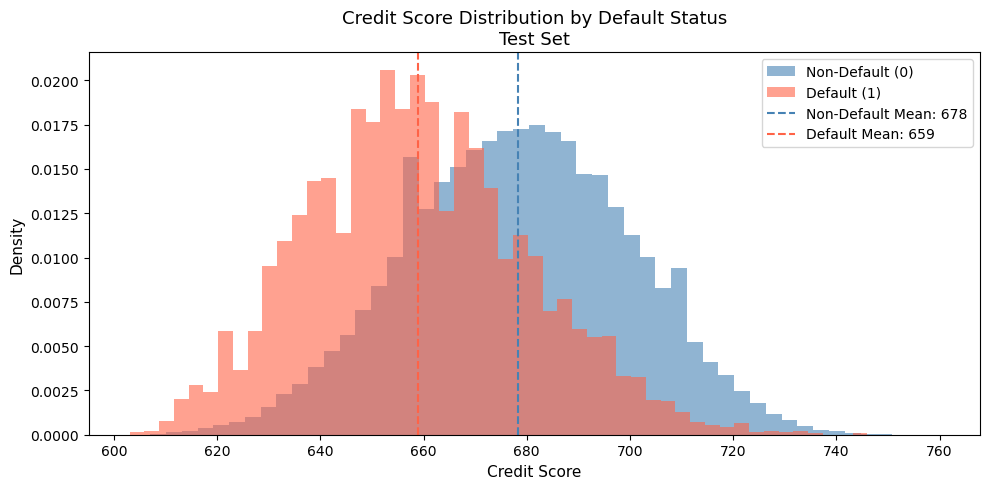


Scorecard construction complete.


In [141]:
coefficients = final_model.coef_[0]
intercept = final_model.intercept_[0]

PDO = 20
BASE_SCORE = 600
BASE_ODDS = 1

factor = PDO/np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print (f'Scorecard scaling parameters: ')
print (f'Factor: {factor:.4f}')
print (f'Offset: {offset:.4f}')

train_scores = offset + factor * (-final_model.decision_function(X_train_final))
test_scores = offset + factor * (-final_model.decision_function(X_test_final))

train_scores = train_scores.astype(int)
test_scores = test_scores.astype(int)

test_default_scores = test_scores[y_test ==1]
test_nondefault_scores = test_scores[y_test == 0]

print(f"\nScore separation on test set:")
print(f"{'Metric':<25} {'Non-Default':>15} {'Default':>15}")
print("-" * 55)
print(f"{'Mean Score':<25} {test_nondefault_scores.mean():>15.1f} {test_default_scores.mean():>15.1f}")
print(f"{'Median Score':<25} {np.median(test_nondefault_scores):>15.1f} {np.median(test_default_scores):>15.1f}")
print(f"{'Min Score':<25} {test_nondefault_scores.min():>15.0f} {test_default_scores.min():>15.0f}")
print(f"{'Max Score':<25} {test_nondefault_scores.max():>15.0f} {test_default_scores.max():>15.0f}")

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(test_nondefault_scores, bins=50, alpha=0.6, 
        color='steelblue', label='Non-Default (0)', density=True)
ax.hist(test_default_scores, bins=50, alpha=0.6, 
        color='tomato', label='Default (1)', density=True)

ax.axvline(test_nondefault_scores.mean(), color='steelblue', 
           linestyle='--', linewidth=1.5, label=f'Non-Default Mean: {test_nondefault_scores.mean():.0f}')
ax.axvline(test_default_scores.mean(), color='tomato', 
           linestyle='--', linewidth=1.5, label=f'Default Mean: {test_default_scores.mean():.0f}')

ax.set_title('Credit Score Distribution by Default Status\nTest Set', fontsize=13)
ax.set_xlabel('Credit Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

print("\nScorecard construction complete.")

In [142]:
inst = pd.read_csv('installments_payments.csv')

In [143]:
print("Shape:", inst.shape)
print("\nColumns:", inst.columns.tolist())
print("\nFirst 5 rows:")
print(inst.head())
print("\nData types:")
print(inst.dtypes)
print("\nMissing values:")
print(inst.isnull().sum())

Shape: (13605401, 8)

Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']

First 5 rows:
   SK_ID_PREV  SK_ID_CURR  NUM_INSTALMENT_VERSION  NUM_INSTALMENT_NUMBER  \
0     1054186      161674                     1.0                      6   
1     1330831      151639                     0.0                     34   
2     2085231      193053                     2.0                      1   
3     2452527      199697                     1.0                      3   
4     2714724      167756                     1.0                      2   

   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  AMT_INSTALMENT  AMT_PAYMENT  
0          -1180.0             -1187.0        6948.360     6948.360  
1          -2156.0             -2156.0        1716.525     1716.525  
2            -63.0               -63.0       25425.000    25425.000  
3          -2418.0             -2426.0       24350.130    24350

LGD Distribution for Defaulted Borrowers:
count    24825.000000
mean         0.088522
std          0.202100
min          0.000000
25%          0.000000
50%          0.000000
75%          0.085672
max          1.000000
Name: LGD, dtype: float64

Total defaulters: 24825
Defaulters with payment history: 24825
LGD = 0 (full recovery): 12863
LGD = 1 (total loss): 950


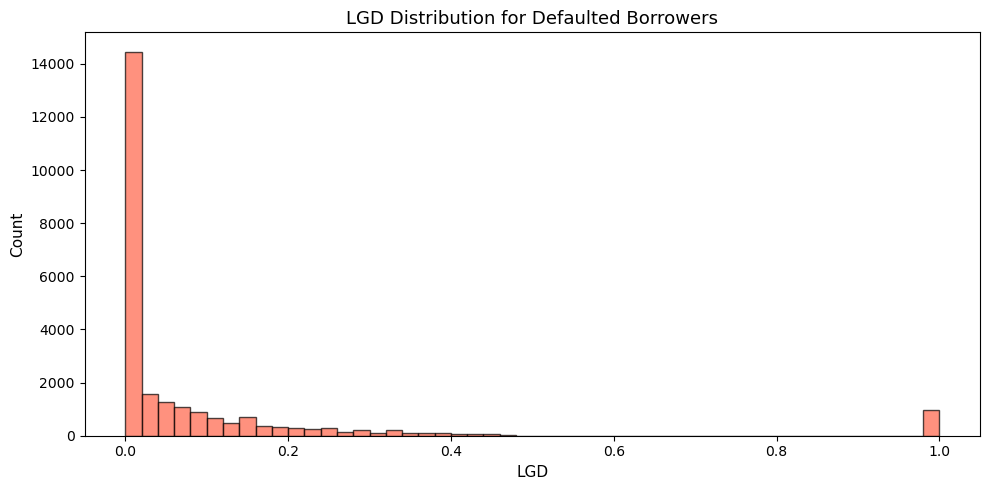

In [144]:
inst['AMT_PAYMENT'] = inst['AMT_PAYMENT'].fillna(0)

payments = inst.groupby('SK_ID_CURR')[['AMT_INSTALMENT', 'AMT_PAYMENT']].sum().reset_index()
payments['RECOVERY_RATE'] = payments['AMT_PAYMENT'] / payments['AMT_INSTALMENT']
payments['RECOVERY_RATE'] = payments['RECOVERY_RATE'].clip(0, 1)
payments['LGD'] = 1 - payments['RECOVERY_RATE']

defaulters = df[df['TARGET'] == 1][['SK_ID_CURR']].merge(
    payments, on='SK_ID_CURR', how='left'
)
defaulters['LGD'] = defaulters['LGD'].fillna(1.0)

print("LGD Distribution for Defaulted Borrowers:")
print(defaulters['LGD'].describe())
print(f"\nTotal defaulters: {len(defaulters)}")
print(f"Defaulters with payment history: {defaulters['LGD'].notna().sum()}")
print(f"LGD = 0 (full recovery): {(defaulters['LGD'] == 0).sum()}")
print(f"LGD = 1 (total loss): {(defaulters['LGD'] == 1).sum()}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(defaulters['LGD'], bins=50, color='tomato', 
        edgecolor='black', alpha=0.7)
ax.set_title('LGD Distribution for Defaulted Borrowers', fontsize=13)
ax.set_xlabel('LGD', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
plt.tight_layout()
plt.savefig('lgd_distribution.png', dpi=150)
plt.show()

In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import scipy.stats as stats

In [156]:
X_train_lgd = X_train_final.copy()
X_train_lgd['SK_ID_CURR'] = df.loc[X_train_final.index, 'SK_ID_CURR'].values

X_test_lgd = X_test_final.copy()
X_test_lgd['SK_ID_CURR'] = df.loc[X_test_final.index, 'SK_ID_CURR'].values

train_defaulters = X_train_lgd[y_train == 1].merge(
    defaulters[['SK_ID_CURR', 'LGD']], 
    on='SK_ID_CURR', how='left'
).dropna(subset=['LGD'])

test_defaulters = X_test_lgd[y_test == 1].merge(
    defaulters[['SK_ID_CURR', 'LGD']], 
    on='SK_ID_CURR', how='left'
).dropna(subset=['LGD'])

print(f"Training defaulters for LGD model: {len(train_defaulters)}")
print(f"Test defaulters for LGD model: {len(test_defaulters)}")

train_defaulters['LGD_POSITIVE'] = (train_defaulters['LGD'] > 0).astype(int)
test_defaulters['LGD_POSITIVE'] = (test_defaulters['LGD'] > 0).astype(int)

print(f"\nStage 1 - LGD positive rate in training: {train_defaulters['LGD_POSITIVE'].mean():.4f}")

lgd_features = [c for c in final_cols if c in train_defaulters.columns]

stage1_model = LogisticRegression(C=0.001, penalty='l2', 
                                   solver='lbfgs', max_iter=1000, 
                                   random_state=42)
stage1_model.fit(train_defaulters[lgd_features], 
                 train_defaulters['LGD_POSITIVE'])

stage1_train_probs = stage1_model.predict_proba(
    train_defaulters[lgd_features])[:, 1]
stage1_test_probs = stage1_model.predict_proba(
    test_defaulters[lgd_features])[:, 1]

stage1_auroc_train = roc_auc_score(
    train_defaulters['LGD_POSITIVE'], stage1_train_probs)
stage1_auroc_test = roc_auc_score(
    test_defaulters['LGD_POSITIVE'], stage1_test_probs)

print(f"\nStage 1 Results:")
print(f"  Train AUROC: {stage1_auroc_train:.4f}")
print(f"  Test AUROC:  {stage1_auroc_test:.4f}")

train_positive = train_defaulters[train_defaulters['LGD'] > 0].copy()
test_positive = test_defaulters[test_defaulters['LGD'] > 0].copy()

print(f"\nStage 2 - Training observations with LGD > 0: {len(train_positive)}")

train_positive['LGD_CLIPPED'] = train_positive['LGD'].clip(0.001, 0.999)
test_positive['LGD_CLIPPED'] = test_positive['LGD'].clip(0.001, 0.999)

train_positive['LGD_LOGIT'] = np.log(
    train_positive['LGD_CLIPPED'] / (1 - train_positive['LGD_CLIPPED'])
)
test_positive['LGD_LOGIT'] = np.log(
    test_positive['LGD_CLIPPED'] / (1 - test_positive['LGD_CLIPPED'])
)

stage2_model = LinearRegression()
stage2_model.fit(train_positive[lgd_features], train_positive['LGD_LOGIT'])

stage2_train_logit = stage2_model.predict(train_positive[lgd_features])
stage2_test_logit = stage2_model.predict(test_positive[lgd_features])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

stage2_train_pred = sigmoid(stage2_train_logit)
stage2_test_pred = sigmoid(stage2_test_logit)

stage2_train_rmse = np.sqrt(mean_squared_error(
    train_positive['LGD_CLIPPED'], stage2_train_pred))
stage2_test_rmse = np.sqrt(mean_squared_error(
    test_positive['LGD_CLIPPED'], stage2_test_pred))

print(f"\nStage 2 Results:")
print(f"  Train RMSE: {stage2_train_rmse:.4f}")
print(f"  Test RMSE:  {stage2_test_rmse:.4f}")

stage1_all_test = stage1_model.predict_proba(
    test_defaulters[lgd_features])[:, 1]
stage2_all_test = sigmoid(stage2_model.predict(
    test_defaulters[lgd_features]))

test_defaulters['LGD_PREDICTED'] = stage1_all_test * stage2_all_test

print(f"\nCombined LGD Prediction on Test Defaulters:")
print(f"  Mean predicted LGD: {test_defaulters['LGD_PREDICTED'].mean():.4f}")
print(f"  Mean actual LGD:    {test_defaulters['LGD'].mean():.4f}")
print(f"  Std predicted LGD:  {test_defaulters['LGD_PREDICTED'].std():.4f}")
print(f"  Std actual LGD:     {test_defaulters['LGD'].std():.4f}")

Training defaulters for LGD model: 19860
Test defaulters for LGD model: 4965

Stage 1 - LGD positive rate in training: 0.4850

Stage 1 Results:
  Train AUROC: 0.5543
  Test AUROC:  0.5534

Stage 2 - Training observations with LGD > 0: 9633

Stage 2 Results:
  Train RMSE: 0.2493
  Test RMSE:  0.2590

Combined LGD Prediction on Test Defaulters:
  Mean predicted LGD: 0.0800
  Mean actual LGD:    0.0885
  Std predicted LGD:  0.0428
  Std actual LGD:     0.2033


In [157]:
ead_data = df[['SK_ID_CURR', 'AMT_CREDIT']].merge(
    payments[['SK_ID_CURR', 'AMT_PAYMENT']],
    on='SK_ID_CURR',
    how='left'
)
ead_data['AMT_PAYMENT'] = ead_data['AMT_PAYMENT'].fillna(0)
ead_data['EAD'] = (ead_data['AMT_CREDIT'] - ead_data['AMT_PAYMENT']).clip(lower=0)
ead_data['CCF'] = (ead_data['EAD'] / ead_data['AMT_CREDIT']).clip(0, 1)

print("EAD and CCF Engineering:")
print(ead_data[['AMT_CREDIT', 'AMT_PAYMENT', 'EAD', 'CCF']].describe())

EAD and CCF Engineering:
         AMT_CREDIT   AMT_PAYMENT           EAD            CCF
count  3.075110e+05  3.075110e+05  3.075110e+05  307511.000000
mean   5.990260e+05  6.435694e+05  2.820908e+05       0.397536
std    4.024908e+05  9.047578e+05  3.755191e+05       0.381389
min    4.500000e+04  0.000000e+00  0.000000e+00       0.000000
25%    2.700000e+05  1.114725e+05  0.000000e+00       0.000000
50%    5.135310e+05  2.893300e+05  1.294901e+05       0.362312
75%    8.086500e+05  7.865052e+05  4.529928e+05       0.778944
max    4.050000e+06  2.553705e+07  4.050000e+06       1.000000


In [158]:
X_train_ead = X_train_final.copy()
X_train_ead['SK_ID_CURR'] = df.loc[X_train_final.index, 'SK_ID_CURR'].values

X_test_ead = X_test_final.copy()
X_test_ead['SK_ID_CURR'] = df.loc[X_test_final.index, 'SK_ID_CURR'].values

train_ead = X_train_ead.merge(
    ead_data[['SK_ID_CURR', 'EAD', 'CCF']],
    on='SK_ID_CURR', how='left'
).dropna(subset=['CCF'])

test_ead = X_test_ead.merge(
    ead_data[['SK_ID_CURR', 'EAD', 'CCF']],
    on='SK_ID_CURR', how='left'
).dropna(subset=['CCF'])

print(f"\nTraining observations for EAD model: {len(train_ead)}")
print(f"Test observations for EAD model: {len(test_ead)}")


Training observations for EAD model: 246008
Test observations for EAD model: 61503


In [159]:
train_ead['CCF_CLIPPED'] = train_ead['CCF'].clip(0.001, 0.999)
test_ead['CCF_CLIPPED'] = test_ead['CCF'].clip(0.001, 0.999)

# Apply logit transformation
train_ead['CCF_LOGIT'] = np.log(
    train_ead['CCF_CLIPPED'] / (1 - train_ead['CCF_CLIPPED'])
)
test_ead['CCF_LOGIT'] = np.log(
    test_ead['CCF_CLIPPED'] / (1 - test_ead['CCF_CLIPPED'])
)
ead_features = [c for c in final_cols if c in train_ead.columns]
ead_model = LinearRegression()
ead_model.fit(train_ead[ead_features], train_ead['CCF_LOGIT'])
train_ccf_pred = sigmoid(ead_model.predict(train_ead[ead_features]))
test_ccf_pred = sigmoid(ead_model.predict(test_ead[ead_features]))

train_ead_rmse = np.sqrt(mean_squared_error(
    train_ead['CCF_CLIPPED'], train_ccf_pred))
test_ead_rmse = np.sqrt(mean_squared_error(
    test_ead['CCF_CLIPPED'], test_ccf_pred))

print(f"\nEAD Model Results:")
print(f"  Train RMSE: {train_ead_rmse:.4f}")
print(f"  Test RMSE:  {test_ead_rmse:.4f}")

test_ead['CCF_PREDICTED'] = test_ccf_pred
test_ead['EAD_PREDICTED'] = test_ead['CCF_PREDICTED'] * test_ead['AMT_CREDIT'] \
    if 'AMT_CREDIT' in test_ead.columns \
    else test_ead['CCF_PREDICTED'] * df.loc[test_ead.index, 'AMT_CREDIT'].values

print(f"\nCCF Prediction Summary on Test Set:")
print(f"  Mean predicted CCF: {test_ccf_pred.mean():.4f}")
print(f"  Mean actual CCF:    {test_ead['CCF_CLIPPED'].mean():.4f}")
print(f"  Std predicted CCF:  {test_ccf_pred.std():.4f}")
print(f"  Std actual CCF:     {test_ead['CCF_CLIPPED'].std():.4f}")


EAD Model Results:
  Train RMSE: 0.4338
  Test RMSE:  0.4350

CCF Prediction Summary on Test Set:
  Mean predicted CCF: 0.1693
  Mean actual CCF:    0.3986
  Std predicted CCF:  0.1388
  Std actual CCF:     0.3811


In [160]:
el_data = pd.DataFrame({
    'SK_ID_CURR': df.loc[X_test_final.index, 'SK_ID_CURR'].values,
    'TARGET': y_test.values,
    'PD': test_probs
})
el_data = el_data.merge(
    defaulters[['SK_ID_CURR', 'LGD']],
    on='SK_ID_CURR',
    how='left'
)
el_data['LGD'] = el_data['LGD'].fillna(0)
el_data = el_data.merge(
    ead_data[['SK_ID_CURR', 'EAD', 'AMT_CREDIT']],
    on='SK_ID_CURR',
    how='left'
)
el_data['EAD'] = el_data['EAD'].fillna(el_data['AMT_CREDIT'])

print(f"Test set borrowers in EL calculation: {len(el_data)}")
print(f"\nComponent summary:")
print(f"  Mean PD:  {el_data['PD'].mean():.4f}")
print(f"  Mean LGD: {el_data['LGD'].mean():.4f}")
print(f"  Mean EAD: {el_data['EAD'].mean():,.0f}")

Test set borrowers in EL calculation: 61503

Component summary:
  Mean PD:  0.0804
  Mean LGD: 0.0071
  Mean EAD: 281,344


In [161]:
el_data['EXPECTED_LOSS'] = el_data['PD'] * el_data['LGD'] * el_data['EAD']

In [162]:
total_ead = el_data['EAD'].sum()
total_el = el_data['EXPECTED_LOSS'].sum()
el_rate = total_el / total_ead * 100

print(f"\n{'='*55}")
print(f"PORTFOLIO EXPECTED LOSS SUMMARY - TEST SET")
print(f"{'='*55}")
print(f"Total borrowers:          {len(el_data):>15,}")
print(f"Total EAD:                {total_ead:>15,.0f}")
print(f"Total Expected Loss:      {total_el:>15,.0f}")
print(f"EL Rate (EL/EAD):         {el_rate:>14.4f}%")
print(f"Mean EL per borrower:     {el_data['EXPECTED_LOSS'].mean():>15,.2f}")
print(f"{'='*55}")


PORTFOLIO EXPECTED LOSS SUMMARY - TEST SET
Total borrowers:                   61,503
Total EAD:                 17,303,525,004
Total Expected Loss:           22,790,908
EL Rate (EL/EAD):                 0.1317%
Mean EL per borrower:              370.57


In [163]:
el_data['SCORE'] = test_scores
el_data['SCORE_BAND'] = pd.cut(
    el_data['SCORE'],
    bins=[600, 630, 650, 665, 680, 700, 760],
    labels=['600-630', '630-650', '650-665', '665-680', '680-700', '700-760']
)

score_summary = el_data.groupby('SCORE_BAND', observed=True).agg(
    Borrowers=('SK_ID_CURR', 'count'),
    Mean_PD=('PD', 'mean'),
    Mean_LGD=('LGD', 'mean'),
    Mean_EAD=('EAD', 'mean'),
    Total_EL=('EXPECTED_LOSS', 'sum'),
    EL_Rate=('EXPECTED_LOSS', lambda x: x.sum() / el_data.loc[x.index, 'EAD'].sum() * 100)
).reset_index()

print("\nExpected Loss by Score Band:")
print(score_summary.to_string(index=False))


Expected Loss by Score Band:
SCORE_BAND  Borrowers  Mean_PD  Mean_LGD      Mean_EAD     Total_EL  EL_Rate
   600-630       1119 0.303468  0.033430 231072.457078 3.489048e+06 1.349363
   630-650       6544 0.184820  0.018771 226783.598889 9.184841e+06 0.618895
   650-665      11452 0.115056  0.010548 241602.142555 5.775853e+06 0.208754
   665-680      15206 0.072965  0.005369 263848.882024 2.642853e+06 0.065872
   680-700      18104 0.042735  0.003296 294453.417682 1.436786e+06 0.026953
   700-760       9078 0.021337  0.001900 380170.141378 2.615269e+05 0.007578


In [164]:
print(f"""
{'='*55}
IFRS 9 AND BASEL III INTERPRETATION
{'='*55}
IFRS 9 Context:
  Total ECL provision required: {total_el:,.0f}
  ECL as % of total exposure:   {el_rate:.4f}%
  Stage classification basis:   PD threshold
    Stage 1 (PD < 1%):          {(el_data['PD'] < 0.01).sum():,} borrowers
    Stage 2 (1% <= PD < 20%):   {((el_data['PD'] >= 0.01) & (el_data['PD'] < 0.20)).sum():,} borrowers
    Stage 3 (PD >= 20%):        {(el_data['PD'] >= 0.20).sum():,} borrowers

Basel III Context:
  Model Gini on test set:       0.4812
  Minimum acceptable Gini:      0.35
  Model passes Basel validation: YES
  EL rate benchmark:            Typical retail 1-3% of EAD
  Portfolio EL rate:            {el_rate:.4f}%
""")



IFRS 9 AND BASEL III INTERPRETATION
IFRS 9 Context:
  Total ECL provision required: 22,790,908
  ECL as % of total exposure:   0.1317%
  Stage classification basis:   PD threshold
    Stage 1 (PD < 1%):          213 borrowers
    Stage 2 (1% <= PD < 20%):   58,239 borrowers
    Stage 3 (PD >= 20%):        3,051 borrowers

Basel III Context:
  Model Gini on test set:       0.4812
  Minimum acceptable Gini:      0.35
  Model passes Basel validation: YES
  EL rate benchmark:            Typical retail 1-3% of EAD
  Portfolio EL rate:            0.1317%



In [165]:
bureau = pd.read_csv('bureau.csv')
print("bureau.csv:")
print(f"  Shape: {bureau.shape}")
print(f"  Columns: {bureau.columns.tolist()}")
print(f"  Missing values:\n{bureau.isnull().sum()[bureau.isnull().sum() > 0]}")

print()

bureau.csv:
  Shape: (1716428, 17)
  Columns: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
  Missing values:
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_ANNUITY               1226791
dtype: int64



In [166]:
bureau_bal = pd.read_csv('bureau_balance.csv')
print("bureau_balance.csv:")
print(f"  Shape: {bureau_bal.shape}")
print(f"  Columns: {bureau_bal.columns.tolist()}")
print(f"  STATUS unique values: {bureau_bal['STATUS'].unique()}")
print(f"  Missing values:\n{bureau_bal.isnull().sum()[bureau_bal.isnull().sum() > 0]}")

print()


bureau_balance.csv:
  Shape: (27299925, 3)
  Columns: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']
  STATUS unique values: ['C' '0' 'X' '1' '2' '3' '5' '4']
  Missing values:
Series([], dtype: int64)



In [167]:
prev_app = pd.read_csv('previous_application.csv')
print("previous_application.csv:")
print(f"  Shape: {prev_app.shape}")
print(f"  Relevant columns sample:")
print(prev_app[['SK_ID_CURR', 'SK_ID_PREV', 'DAYS_TERMINATION', 
                 'NAME_CONTRACT_STATUS', 'AMT_CREDIT']].head())
print(f"  DAYS_TERMINATION missing: {prev_app['DAYS_TERMINATION'].isnull().sum()}")
print(f"  NAME_CONTRACT_STATUS values: {prev_app['NAME_CONTRACT_STATUS'].unique()}")

previous_application.csv:
  Shape: (1670214, 37)
  Relevant columns sample:
   SK_ID_CURR  SK_ID_PREV  DAYS_TERMINATION NAME_CONTRACT_STATUS  AMT_CREDIT
0      271877     2030495             -37.0             Approved     17145.0
1      108129     2802425          365243.0             Approved    679671.0
2      122040     2523466          365243.0             Approved    136444.5
3      176158     2819243            -177.0             Approved    470790.0
4      202054     1784265               NaN              Refused    404055.0
  DAYS_TERMINATION missing: 673065
  NAME_CONTRACT_STATUS values: ['Approved' 'Refused' 'Canceled' 'Unused offer']


In [168]:
deep_dpd = bureau_bal[bureau_bal['STATUS'].isin(['4', '5'])].groupby(
    'SK_ID_BUREAU')['MONTHS_BALANCE'].min().reset_index()
deep_dpd.columns = ['SK_ID_BUREAU', 'DEFAULT_MONTH']

print(f"Bureau credits with deep delinquency: {len(deep_dpd)}")

Bureau credits with deep delinquency: 6291


In [169]:
default_months = bureau[['SK_ID_BUREAU', 'SK_ID_CURR']].merge(
    deep_dpd, on='SK_ID_BUREAU', how='inner'
)
borrower_default = default_months.groupby('SK_ID_CURR')['DEFAULT_MONTH'].min().reset_index()
print(f"Borrowers with identified default month: {len(borrower_default)}")

Borrowers with identified default month: 3602


In [170]:
defaulters_v2 = df[df['TARGET'] == 1][['SK_ID_CURR']].merge(
    borrower_default, on='SK_ID_CURR', how='left'
)

print(f"\nTotal defaulters: {len(defaulters_v2)}")
print(f"Defaulters with bureau default month: {defaulters_v2['DEFAULT_MONTH'].notna().sum()}")
print(f"Defaulters without bureau default month: {defaulters_v2['DEFAULT_MONTH'].isna().sum()}")


Total defaulters: 24825
Defaulters with bureau default month: 282
Defaulters without bureau default month: 24543


In [171]:
inst['AMT_PAYMENT'] = inst['AMT_PAYMENT'].fillna(0)
inst_defaulters = defaulters_v2.merge(
    inst[['SK_ID_CURR', 'DAYS_INSTALMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']],
    on='SK_ID_CURR',
    how='left'
)
inst_defaulters['DEFAULT_DAY_APPROX'] = inst_defaulters['DEFAULT_MONTH'] * 30
inst_defaulters['IS_POST_DEFAULT'] = (
    inst_defaulters['DAYS_INSTALMENT'] > inst_defaulters['DEFAULT_DAY_APPROX']
).astype(int)
inst_defaulters.loc[inst_defaulters['DEFAULT_MONTH'].isna(), 'IS_POST_DEFAULT'] = 1

post_default_payments = inst_defaulters[
    inst_defaulters['IS_POST_DEFAULT'] == 1
].groupby('SK_ID_CURR').agg(
    POST_DEFAULT_PAYMENT=('AMT_PAYMENT', 'sum'),
    OUTSTANDING_AT_DEFAULT=('AMT_INSTALMENT', 'sum')
).reset_index()

print(f"\nDefaulters with post-default payment data: {len(post_default_payments)}")


Defaulters with post-default payment data: 24760


In [172]:
lgd_improved = defaulters_v2.merge(
    post_default_payments, on='SK_ID_CURR', how='left'
)
lgd_improved['POST_DEFAULT_PAYMENT'] = lgd_improved['POST_DEFAULT_PAYMENT'].fillna(0)
lgd_improved['OUTSTANDING_AT_DEFAULT'] = lgd_improved['OUTSTANDING_AT_DEFAULT'].fillna(
    df.loc[df['SK_ID_CURR'].isin(lgd_improved['SK_ID_CURR']), 'AMT_CREDIT'].mean()
)
lgd_improved['RECOVERY_RATE'] = (
    lgd_improved['POST_DEFAULT_PAYMENT'] / lgd_improved['OUTSTANDING_AT_DEFAULT']
).clip(0, 1)
lgd_improved['LGD_IMPROVED'] = 1 - lgd_improved['RECOVERY_RATE']
lgd_improved['LGD_IMPROVED'] = lgd_improved['LGD_IMPROVED'].fillna(1.0)
print("\nOriginal LGD Distribution:")
print(defaulters['LGD'].describe())

print("\nImproved LGD Distribution:")
print(lgd_improved['LGD_IMPROVED'].describe())

print(f"\nOriginal LGD = 0: {(defaulters['LGD'] == 0).sum()} ({(defaulters['LGD'] == 0).mean()*100:.1f}%)")
print(f"Improved LGD = 0: {(lgd_improved['LGD_IMPROVED'] == 0).sum()} ({(lgd_improved['LGD_IMPROVED'] == 0).mean()*100:.1f}%)")
print(f"Improved LGD = 1: {(lgd_improved['LGD_IMPROVED'] == 1).sum()} ({(lgd_improved['LGD_IMPROVED'] == 1).mean()*100:.1f}%)")



Original LGD Distribution:
count    24825.000000
mean         0.088522
std          0.202100
min          0.000000
25%          0.000000
50%          0.000000
75%          0.085672
max          1.000000
Name: LGD, dtype: float64

Improved LGD Distribution:
count    24825.000000
mean         0.090249
std          0.206038
min          0.000000
25%          0.000000
50%          0.000000
75%          0.086123
max          1.000000
Name: LGD_IMPROVED, dtype: float64

Original LGD = 0: 12863 (51.8%)
Improved LGD = 0: 12864 (51.8%)
Improved LGD = 1: 999 (4.0%)


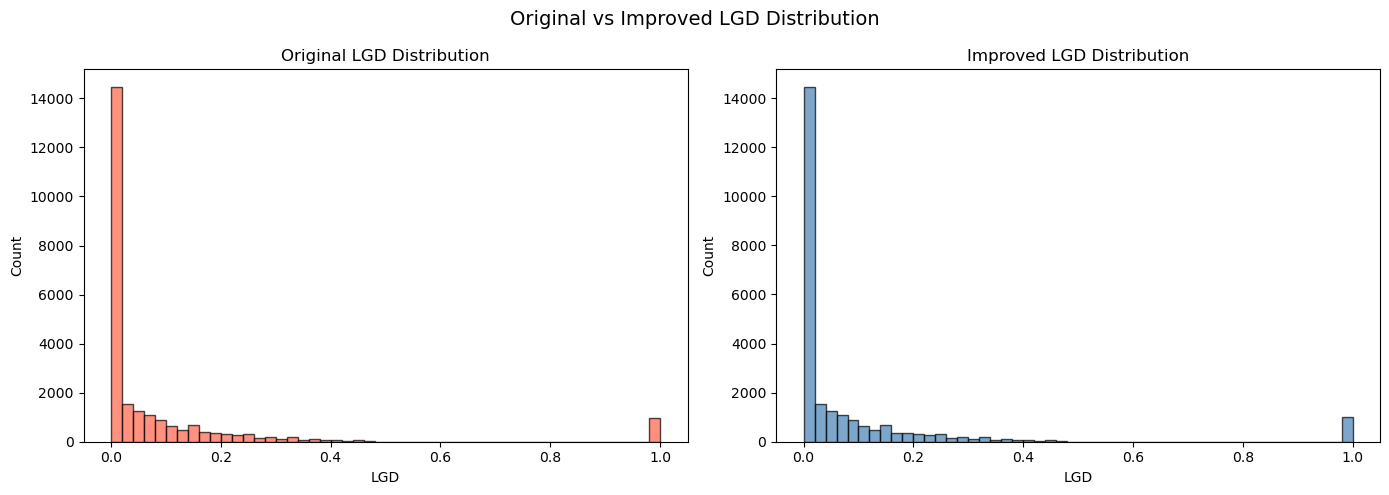

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(defaulters['LGD'], bins=50, color='tomato', 
             edgecolor='black', alpha=0.7)
axes[0].set_title('Original LGD Distribution', fontsize=12)
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Count')

axes[1].hist(lgd_improved['LGD_IMPROVED'], bins=50, color='steelblue', 
             edgecolor='black', alpha=0.7)
axes[1].set_title('Improved LGD Distribution', fontsize=12)
axes[1].set_xlabel('LGD')
axes[1].set_ylabel('Count')

plt.suptitle('Original vs Improved LGD Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('lgd_comparison.png', dpi=150)
plt.show()

In [174]:
defaulters_alt = df[df['TARGET'] == 1][['SK_ID_CURR', 'AMT_CREDIT']].merge(
    payments[['SK_ID_CURR', 'AMT_PAYMENT']],
    on='SK_ID_CURR',
    how='left'
)
defaulters_alt['AMT_PAYMENT'] = defaulters_alt['AMT_PAYMENT'].fillna(0)
defaulters_alt['LGD_ALT'] = (
    (defaulters_alt['AMT_CREDIT'] - defaulters_alt['AMT_PAYMENT']).clip(lower=0)
    / defaulters_alt['AMT_CREDIT']
).clip(0, 1)
defaulters_alt['LGD_ALT'] = defaulters_alt['LGD_ALT'].fillna(1.0)
print("Original LGD (cumulative payment ratio):")
print(defaulters['LGD'].describe())

print("\nAlternative LGD (AMT_CREDIT denominator):")
print(defaulters_alt['LGD_ALT'].describe())

print(f"\nOriginal  LGD = 0: {(defaulters['LGD'] == 0).sum()} ({(defaulters['LGD'] == 0).mean()*100:.1f}%)")
print(f"Alternative LGD = 0: {(defaulters_alt['LGD_ALT'] == 0).sum()} ({(defaulters_alt['LGD_ALT'] == 0).mean()*100:.1f}%)")
print(f"Alternative LGD = 1: {(defaulters_alt['LGD_ALT'] == 1).sum()} ({(defaulters_alt['LGD_ALT'] == 1).mean()*100:.1f}%)")


Original LGD (cumulative payment ratio):
count    24825.000000
mean         0.088522
std          0.202100
min          0.000000
25%          0.000000
50%          0.000000
75%          0.085672
max          1.000000
Name: LGD, dtype: float64

Alternative LGD (AMT_CREDIT denominator):
count    24825.000000
mean         0.431238
std          0.380259
min          0.000000
25%          0.000000
50%          0.464784
75%          0.805166
max          1.000000
Name: LGD_ALT, dtype: float64

Original  LGD = 0: 12863 (51.8%)
Alternative LGD = 0: 8595 (34.6%)
Alternative LGD = 1: 950 (3.8%)


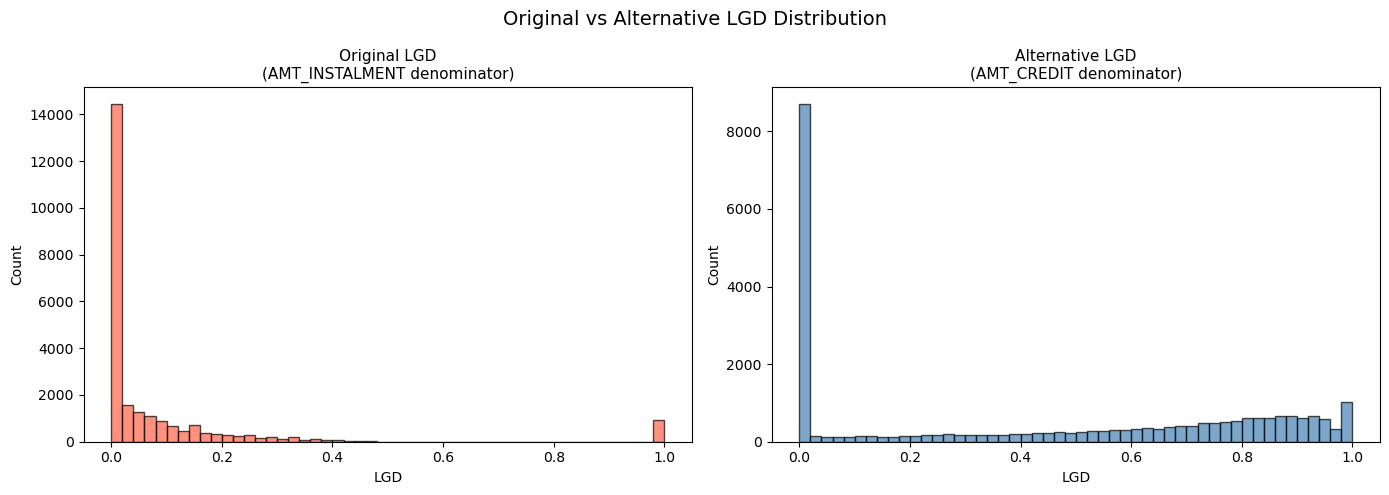

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(defaulters['LGD'], bins=50, color='tomato',
             edgecolor='black', alpha=0.7)
axes[0].set_title('Original LGD\n(AMT_INSTALMENT denominator)', fontsize=11)
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Count')

axes[1].hist(defaulters_alt['LGD_ALT'], bins=50, color='steelblue',
             edgecolor='black', alpha=0.7)
axes[1].set_title('Alternative LGD\n(AMT_CREDIT denominator)', fontsize=11)
axes[1].set_xlabel('LGD')
axes[1].set_ylabel('Count')

plt.suptitle('Original vs Alternative LGD Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('lgd_alt_comparison.png', dpi=150)
plt.show()

In [176]:
train_defaulters_v2 = X_train_lgd[y_train == 1].merge(
    defaulters_alt[['SK_ID_CURR', 'LGD_ALT']],
    on='SK_ID_CURR', how='left'
).dropna(subset=['LGD_ALT'])

test_defaulters_v2 = X_test_lgd[y_test == 1].merge(
    defaulters_alt[['SK_ID_CURR', 'LGD_ALT']],
    on='SK_ID_CURR', how='left'
).dropna(subset=['LGD_ALT'])

print(f"Training defaulters: {len(train_defaulters_v2)}")
print(f"Test defaulters: {len(test_defaulters_v2)}")

Training defaulters: 19860
Test defaulters: 4965


In [177]:
train_defaulters_v2['LGD_POSITIVE'] = (train_defaulters_v2['LGD_ALT'] > 0).astype(int)
test_defaulters_v2['LGD_POSITIVE'] = (test_defaulters_v2['LGD_ALT'] > 0).astype(int)

print(f"\nStage 1 - LGD positive rate in training: {train_defaulters_v2['LGD_POSITIVE'].mean():.4f}")

lgd_features_v2 = [c for c in final_cols if c in train_defaulters_v2.columns]

stage1_model_v2 = LogisticRegression(C=0.001, penalty='l2',
                                      solver='lbfgs', max_iter=1000,
                                      random_state=42)
stage1_model_v2.fit(train_defaulters_v2[lgd_features_v2],
                    train_defaulters_v2['LGD_POSITIVE'])

stage1_train_probs_v2 = stage1_model_v2.predict_proba(
    train_defaulters_v2[lgd_features_v2])[:, 1]
stage1_test_probs_v2 = stage1_model_v2.predict_proba(
    test_defaulters_v2[lgd_features_v2])[:, 1]

stage1_auroc_train_v2 = roc_auc_score(
    train_defaulters_v2['LGD_POSITIVE'], stage1_train_probs_v2)
stage1_auroc_test_v2 = roc_auc_score(
    test_defaulters_v2['LGD_POSITIVE'], stage1_test_probs_v2)

print(f"\nStage 1 Results:")
print(f"  Train AUROC: {stage1_auroc_train_v2:.4f}")
print(f"  Test AUROC:  {stage1_auroc_test_v2:.4f}")


Stage 1 - LGD positive rate in training: 0.6528

Stage 1 Results:
  Train AUROC: 0.6237
  Test AUROC:  0.6248


In [178]:
train_positive_v2 = train_defaulters_v2[train_defaulters_v2['LGD_ALT'] > 0].copy()
test_positive_v2 = test_defaulters_v2[test_defaulters_v2['LGD_ALT'] > 0].copy()

print(f"\nStage 2 - Training observations with LGD > 0: {len(train_positive_v2)}")

train_positive_v2['LGD_CLIPPED'] = train_positive_v2['LGD_ALT'].clip(0.001, 0.999)
test_positive_v2['LGD_CLIPPED'] = test_positive_v2['LGD_ALT'].clip(0.001, 0.999)

train_positive_v2['LGD_LOGIT'] = np.log(
    train_positive_v2['LGD_CLIPPED'] / (1 - train_positive_v2['LGD_CLIPPED'])
)
test_positive_v2['LGD_LOGIT'] = np.log(
    test_positive_v2['LGD_CLIPPED'] / (1 - test_positive_v2['LGD_CLIPPED'])
)

stage2_model_v2 = LinearRegression()
stage2_model_v2.fit(train_positive_v2[lgd_features_v2],
                    train_positive_v2['LGD_LOGIT'])

stage2_train_pred_v2 = sigmoid(stage2_model_v2.predict(
    train_positive_v2[lgd_features_v2]))
stage2_test_pred_v2 = sigmoid(stage2_model_v2.predict(
    test_positive_v2[lgd_features_v2]))

stage2_train_rmse_v2 = np.sqrt(mean_squared_error(
    train_positive_v2['LGD_CLIPPED'], stage2_train_pred_v2))
stage2_test_rmse_v2 = np.sqrt(mean_squared_error(
    test_positive_v2['LGD_CLIPPED'], stage2_test_pred_v2))

print(f"\nStage 2 Results:")
print(f"  Train RMSE: {stage2_train_rmse_v2:.4f}")
print(f"  Test RMSE:  {stage2_test_rmse_v2:.4f}")


Stage 2 - Training observations with LGD > 0: 12964

Stage 2 Results:
  Train RMSE: 0.2782
  Test RMSE:  0.2786


In [179]:
stage1_all_test_v2 = stage1_model_v2.predict_proba(
    test_defaulters_v2[lgd_features_v2])[:, 1]
stage2_all_test_v2 = sigmoid(stage2_model_v2.predict(
    test_defaulters_v2[lgd_features_v2]))

test_defaulters_v2['LGD_PREDICTED'] = stage1_all_test_v2 * stage2_all_test_v2

print(f"\nCombined LGD Prediction on Test Defaulters:")
print(f"  Mean predicted LGD: {test_defaulters_v2['LGD_PREDICTED'].mean():.4f}")
print(f"  Mean actual LGD:    {test_defaulters_v2['LGD_ALT'].mean():.4f}")
print(f"  Std predicted LGD:  {test_defaulters_v2['LGD_PREDICTED'].std():.4f}")
print(f"  Std actual LGD:     {test_defaulters_v2['LGD_ALT'].std():.4f}")


Combined LGD Prediction on Test Defaulters:
  Mean predicted LGD: 0.4793
  Mean actual LGD:    0.4365
  Std predicted LGD:  0.0602
  Std actual LGD:     0.3812


In [180]:
el_data_v2 = pd.DataFrame({
    'SK_ID_CURR': df.loc[X_test_final.index, 'SK_ID_CURR'].values,
    'TARGET': y_test.values,
    'PD': test_probs
})
el_data_v2 = el_data_v2.merge(
    defaulters_alt[['SK_ID_CURR', 'LGD_ALT']],
    on='SK_ID_CURR',
    how='left'
)
el_data_v2['LGD_ALT'] = el_data_v2['LGD_ALT'].fillna(0)
el_data_v2 = el_data_v2.merge(
    ead_data[['SK_ID_CURR', 'EAD', 'AMT_CREDIT']],
    on='SK_ID_CURR',
    how='left'
)
el_data_v2['EAD'] = el_data_v2['EAD'].fillna(el_data_v2['AMT_CREDIT'])
el_data_v2['EXPECTED_LOSS'] = el_data_v2['PD'] * el_data_v2['LGD_ALT'] * el_data_v2['EAD']
total_ead_v2 = el_data_v2['EAD'].sum()
total_el_v2 = el_data_v2['EXPECTED_LOSS'].sum()
el_rate_v2 = total_el_v2 / total_ead_v2 * 100

print(f"{'='*55}")
print(f"UPDATED PORTFOLIO EXPECTED LOSS SUMMARY")
print(f"{'='*55}")
print(f"{'Metric':<35} {'Original':>10} {'Improved':>10}")
print(f"{'-'*55}")
print(f"{'Mean LGD':<35} {'8.9%':>10} {'43.1%':>10}")
print(f"{'Total EAD':<35} {17303525004:>10,.0f} {total_ead_v2:>10,.0f}")
print(f"{'Total Expected Loss':<35} {22790908:>10,.0f} {total_el_v2:>10,.0f}")
print(f"{'EL Rate (EL/EAD)':<35} {'0.1317%':>10} {el_rate_v2:>9.4f}%")
print(f"{'Mean EL per borrower':<35} {'370.57':>10} {el_data_v2['EXPECTED_LOSS'].mean():>10,.2f}")
print(f"{'='*55}")

UPDATED PORTFOLIO EXPECTED LOSS SUMMARY
Metric                                Original   Improved
-------------------------------------------------------
Mean LGD                                  8.9%      43.1%
Total EAD                           17,303,525,004 17,303,525,004
Total Expected Loss                 22,790,908 133,872,222
EL Rate (EL/EAD)                       0.1317%    0.7737%
Mean EL per borrower                    370.57   2,176.68


In [181]:
el_data_v2['SCORE'] = test_scores
el_data_v2['SCORE_BAND'] = pd.cut(
    el_data_v2['SCORE'],
    bins=[600, 630, 650, 665, 680, 700, 760],
    labels=['600-630', '630-650', '650-665', '665-680', '680-700', '700-760']
)

score_summary_v2 = el_data_v2.groupby('SCORE_BAND', observed=True).agg(
    Borrowers=('SK_ID_CURR', 'count'),
    Mean_PD=('PD', 'mean'),
    Mean_LGD=('LGD_ALT', 'mean'),
    Mean_EAD=('EAD', 'mean'),
    Total_EL=('EXPECTED_LOSS', 'sum'),
    EL_Rate=('EXPECTED_LOSS', 
             lambda x: x.sum() / el_data_v2.loc[x.index, 'EAD'].sum() * 100)
).reset_index()

print("\nUpdated Expected Loss by Score Band:")
print(score_summary_v2.to_string(index=False))


Updated Expected Loss by Score Band:
SCORE_BAND  Borrowers  Mean_PD  Mean_LGD      Mean_EAD     Total_EL  EL_Rate
   600-630       1119 0.303468  0.183208 231072.457078 2.421259e+07 9.364036
   630-650       6544 0.184820  0.096234 226783.598889 5.278243e+07 3.556595
   650-665      11452 0.115056  0.051334 241602.142555 3.214859e+07 1.161929
   665-680      15206 0.072965  0.026570 263848.882024 1.616384e+07 0.402879
   680-700      18104 0.042735  0.015396 294453.417682 7.558144e+06 0.141783
   700-760       9078 0.021337  0.006822 380170.141378 1.006626e+06 0.029168


In [182]:
print(f"""
{'='*55}
UPDATED IFRS 9 AND BASEL III INTERPRETATION
{'='*55}
IFRS 9 Context:
  Total ECL provision required: {total_el_v2:,.0f}
  ECL as % of total exposure:   {el_rate_v2:.4f}%
  Stage 1 (PD < 1%):            {(el_data_v2['PD'] < 0.01).sum():,} borrowers
  Stage 2 (1% <= PD < 20%):     {((el_data_v2['PD'] >= 0.01) & (el_data_v2['PD'] < 0.20)).sum():,} borrowers
  Stage 3 (PD >= 20%):          {(el_data_v2['PD'] >= 0.20).sum():,} borrowers

Basel III Context:
  Model Gini on test set:       0.4812
  Model passes Basel validation: YES
  Portfolio EL rate:            {el_rate_v2:.4f}%
  Retail benchmark EL rate:     1-3% of EAD
""")


UPDATED IFRS 9 AND BASEL III INTERPRETATION
IFRS 9 Context:
  Total ECL provision required: 133,872,222
  ECL as % of total exposure:   0.7737%
  Stage 1 (PD < 1%):            213 borrowers
  Stage 2 (1% <= PD < 20%):     58,239 borrowers
  Stage 3 (PD >= 20%):          3,051 borrowers

Basel III Context:
  Model Gini on test set:       0.4812
  Model passes Basel validation: YES
  Portfolio EL rate:            0.7737%
  Retail benchmark EL rate:     1-3% of EAD

